In [1]:
!pip install seaborn pandas matplotlib scikit-learn imbalanced-learn joblib



In [2]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

os.makedirs("analytics", exist_ok=True)


In [3]:
titanic = sns.load_dataset("titanic")

print("Dataset loaded successfully!")
print("Shape:", titanic.shape)

display(titanic.head())

Dataset loaded successfully!
Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
titanic.to_csv(
    "analytics/titanic.csv",
    index=False
)

print("Fallback CSV saved successfully.")

Fallback CSV saved successfully.


In [5]:
print(os.path.exists("analytics/titanic.csv"))

True


In [6]:
print("Shape:")
print(titanic.shape)

print("\nColumns:")
print(titanic.columns.tolist())

print("\nData types:")
print(titanic.dtypes)

print("\nFirst 5 rows:")
display(titanic.head())


Shape:
(891, 15)

Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [8]:
display(titanic.describe(include="all"))

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
missing_pct = (
    titanic.isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Missing-value percentage by column:")
display(missing_pct)

Missing-value percentage by column:


,0
deck,77.216611
age,19.865320
embarked,0.224467
embark_town,0.224467
sex,0.000000
pclass,0.000000
survived,0.000000
fare,0.000000
parch,0.000000
sibsp,0.000000


In [10]:
print(titanic.shape)
print(titanic.columns.tolist())
display(missing_pct)

(891, 15)
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


,0
deck,77.216611
age,19.865320
embarked,0.224467
embark_town,0.224467
sex,0.000000
pclass,0.000000
survived,0.000000
fare,0.000000
parch,0.000000
sibsp,0.000000


In [11]:
df = titanic.copy()

In [12]:
df = df.drop(columns=["deck", "embark_town"])

In [13]:
df = df.dropna(subset=["embarked"])

In [14]:
age_median = df["age"].median()

df["age"] = df["age"].fillna(age_median)

print("Age median used for imputation:", age_median)

Age median used for imputation: 28.0


In [15]:
print("Remaining missing values:")
display(
    df.isnull().sum()
)


Remaining missing values:


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [16]:
print("Original shape:", titanic.shape)
print("Cleaned shape:", df.shape)

print("\nRemaining missing values:")
display(
    df.isnull().sum()
)

Original shape: (891, 15)
Cleaned shape: (889, 13)

Remaining missing values:


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [17]:
display(df.head())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,no,True


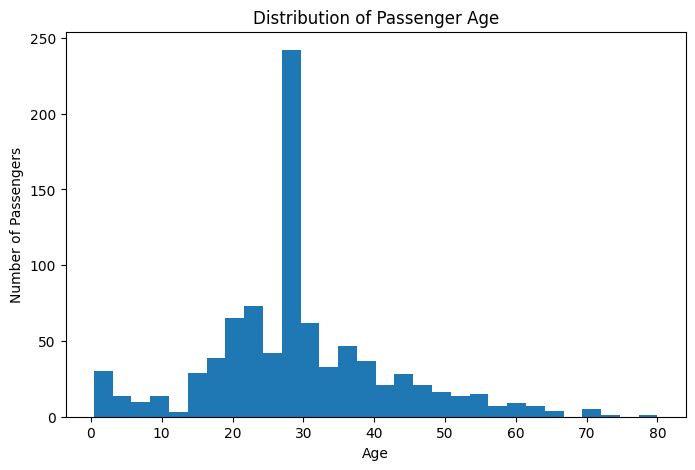

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(df["age"], bins=30)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

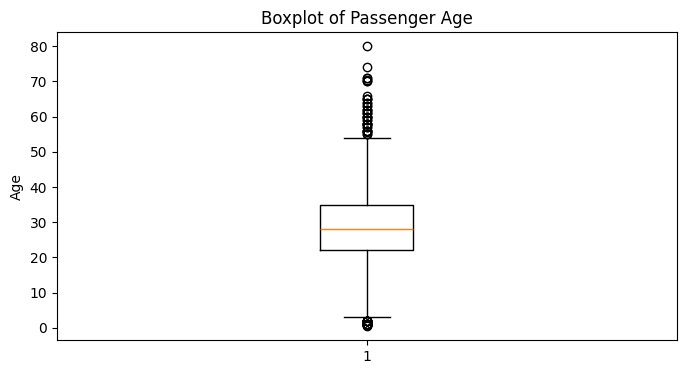

In [19]:
plt.figure(figsize=(8, 4))

plt.boxplot(df["age"])

plt.title("Boxplot of Passenger Age")
plt.ylabel("Age")

plt.show()

In [20]:
Q1_age = df["age"].quantile(0.25)
Q3_age = df["age"].quantile(0.75)

IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_outliers = df[
    (df["age"] < lower_age) |
    (df["age"] > upper_age)
]

print("Age Q1:", Q1_age)
print("Age Q3:", Q3_age)
print("Age IQR:", IQR_age)
print("Lower bound:", lower_age)
print("Upper bound:", upper_age)
print("Number of age outliers:", len(age_outliers))

Age Q1: 22.0
Age Q3: 35.0
Age IQR: 13.0
Lower bound: 2.5
Upper bound: 54.5
Number of age outliers: 65


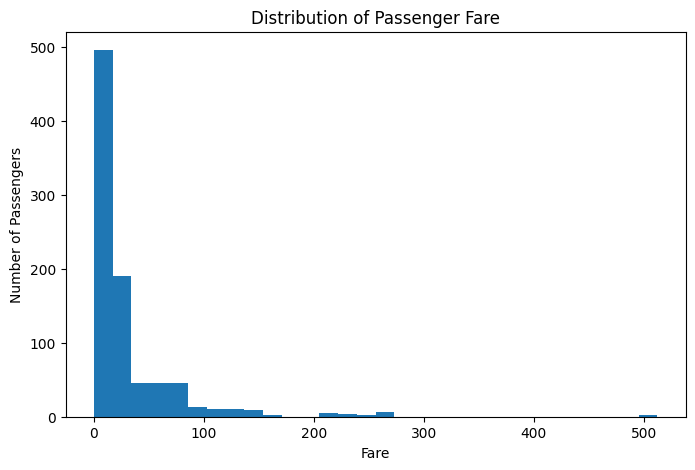

In [21]:
plt.figure(figsize=(8, 5))

plt.hist(df["fare"], bins=30)

plt.title("Distribution of Passenger Fare")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

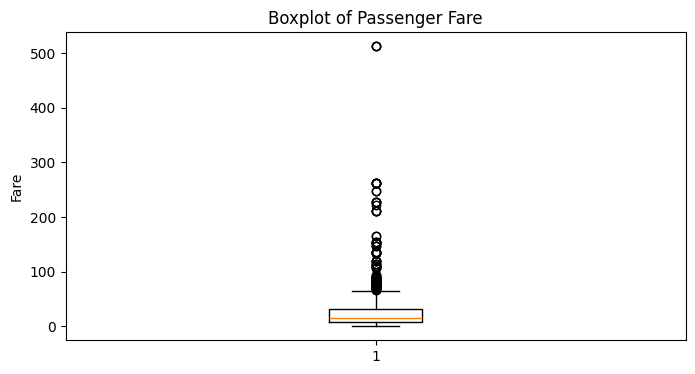

In [22]:
plt.figure(figsize=(8, 4))

plt.boxplot(df["fare"])

plt.title("Boxplot of Passenger Fare")
plt.ylabel("Fare")

plt.show()

In [23]:
Q1_fare = df["fare"].quantile(0.25)
Q3_fare = df["fare"].quantile(0.75)

IQR_fare = Q3_fare - Q1_fare

lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

fare_outliers = df[
    (df["fare"] < lower_fare) |
    (df["fare"] > upper_fare)
]

print("Fare Q1:", Q1_fare)
print("Fare Q3:", Q3_fare)
print("Fare IQR:", IQR_fare)
print("Lower bound:", lower_fare)
print("Upper bound:", upper_fare)
print("Number of fare outliers:", len(fare_outliers))

Fare Q1: 7.8958
Fare Q3: 31.0
Fare IQR: 23.1042
Lower bound: -26.7605
Upper bound: 65.6563
Number of fare outliers: 114


In [24]:
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()[0]
fare_skew = df["fare"].skew()

print("Fare mean:", fare_mean)
print("Fare median:", fare_median)
print("Fare mode:", fare_mode)
print("Fare skewness:", fare_skew)

Fare mean: 32.09668087739032
Fare median: 14.4542
Fare mode: 8.05
Fare skewness: 4.801440211044194


In [25]:
# Survival rate by sex
survival_by_sex = df.groupby("sex")["survived"].mean() * 100

print("Survival Rate by Sex:")
display(survival_by_sex)

# Survival rate by passenger class
survival_by_pclass = df.groupby("pclass")["survived"].mean() * 100

print("\nSurvival Rate by Passenger Class:")
display(survival_by_pclass)

# Survival rate by sex and passenger class
survival_by_sex_pclass = (
    df.groupby(["sex", "pclass"])["survived"]
    .mean()
    .mul(100)
    .reset_index(name="survival_rate")
)

print("\nSurvival Rate by Sex and Passenger Class:")
display(survival_by_sex_pclass)

Survival Rate by Sex:


,survived
sex,
female,74.038462
male,18.890815



Survival Rate by Passenger Class:


,survived
pclass,
1,62.616822
2,47.282609
3,24.236253



Survival Rate by Sex and Passenger Class:


,sex,pclass,survival_rate
0,female,1,96.739130
1,female,2,92.105263
2,female,3,50.000000
3,male,1,36.885246
4,male,2,15.740741
5,male,3,13.544669


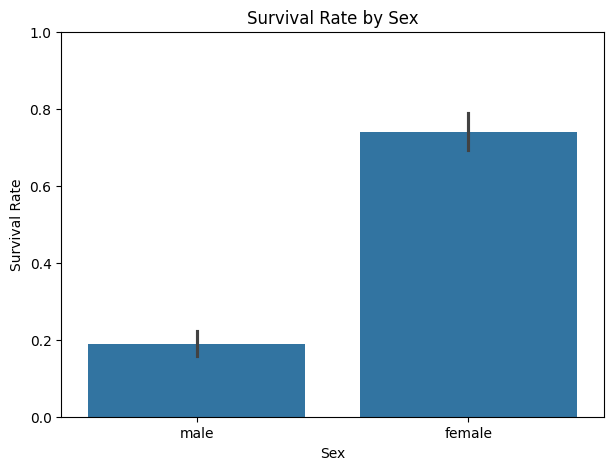

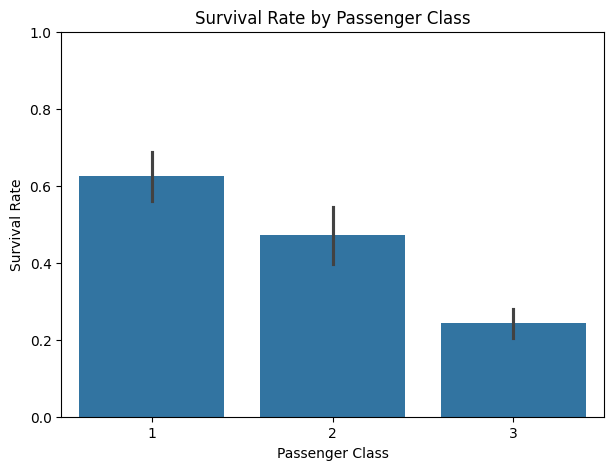

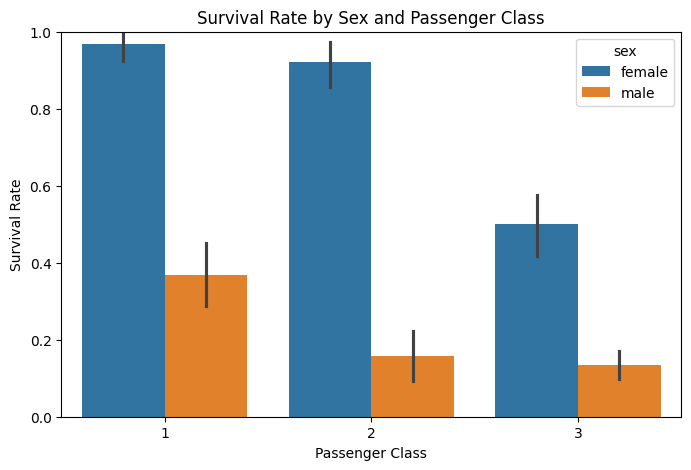

Correlation Matrix:


,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


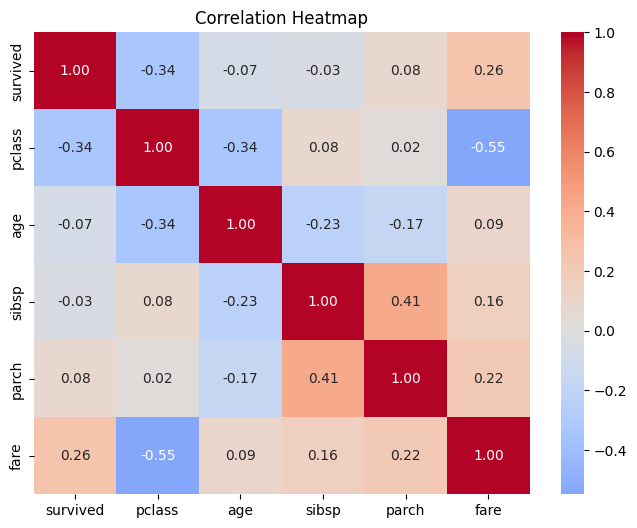

Strongest correlation pairs:
fare vs pclass: -0.548
parch vs sibsp: 0.415
age vs pclass: -0.337
pclass vs survived: -0.336
fare vs survived: 0.255


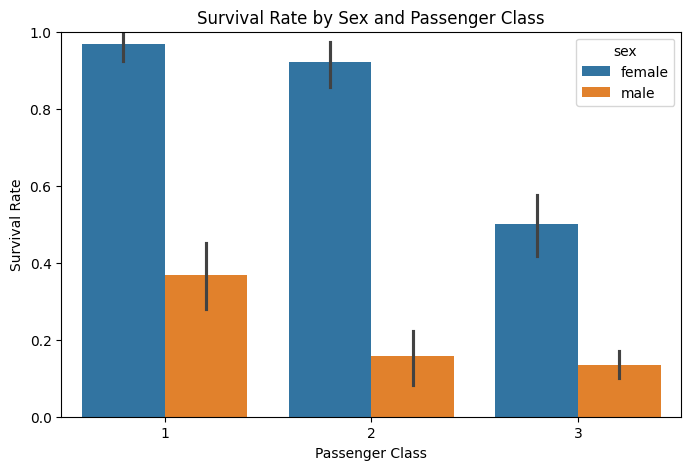

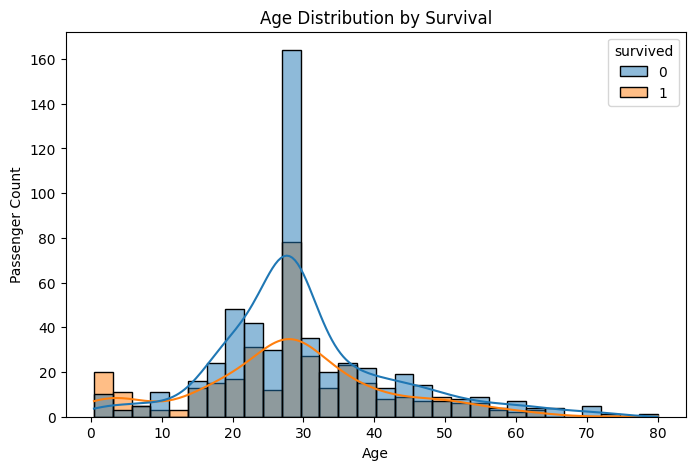

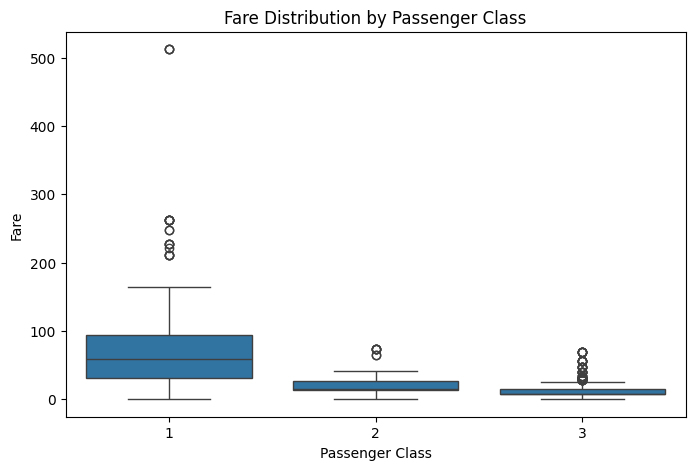

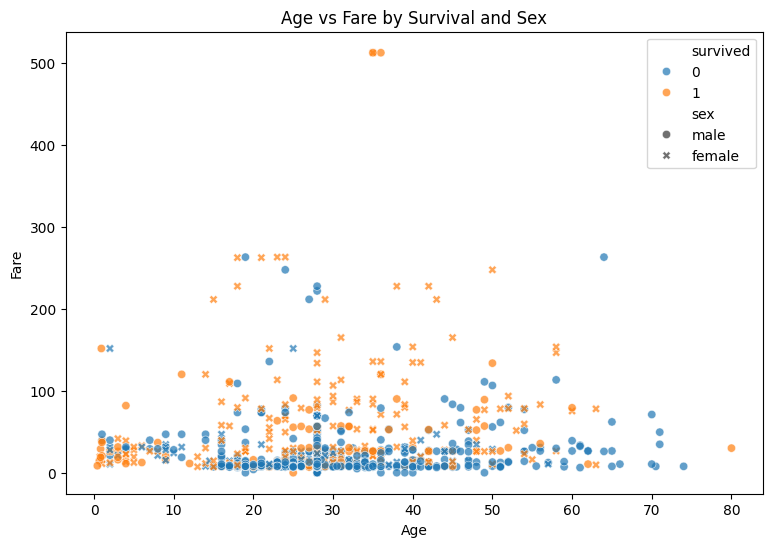


Multivariate interpretation:

1. Survival varied substantially across passenger class and sex,
   with females and higher-class passengers generally showing
   higher survival rates.

2. The age distribution shows that survivors and non-survivors
   were distributed across several age groups, although the
   distributions are not identical.

3. Fare values differ considerably between passenger classes.
   Higher passenger classes generally contain passengers with
   higher fares, while the lower class contains many lower fares
   and several high-fare outliers.

4. The age-versus-fare plot shows that fare has a wide spread
   across ages. Survival is not explained by age or fare alone,
   suggesting that multiple passenger characteristics should
   be considered together.
   
Before standardization:


,age,fare
count,889.000000,889.000000
mean,29.315152,32.096681
std,12.984932,49.697504
min,0.420000,0.000000
25%,22.000000,7.895800
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200



After standardization:


,age,fare
count,8.890000e+02,8.890000e+02
mean,2.717486e-16,1.398706e-16
std,1.000563e+00,1.000563e+00
min,-2.226536e+00,-6.462044e-01
25%,-5.636741e-01,-4.872378e-01
50%,-1.013399e-01,-3.551972e-01
75%,4.380499e-01,-2.207954e-02
max,3.905556e+00,9.668551e+00



Means after standardization:
age     2.717486e-16
fare    1.398706e-16
dtype: float64

Standard deviations after standardization:
age     1.000563
fare    1.000563
dtype: float64
Features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'who', 'adult_male', 'alone']

Target:
survived

Training rows: 711
Testing rows: 178

Training target distribution:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing target distribution:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64
Preprocessing pipeline created successfully.
All three classification models trained successfully.

Logistic Regression

Confusion Matrix:
[[98 12]
 [21 47]]

Accuracy: 0.8146
Precision: 0.7966
Recall: 0.6912
F1: 0.7402
ROC-AUC: 0.8689

Decision Tree

Confusion Matrix:
[[100  10]
 [ 28  40]]

Accuracy: 0.7865
Precision: 0.8
Recall: 0.5882
F1: 0.678
ROC-AUC: 0.8211

Random Forest

Confusion Matrix:
[[95 15]
 [20 48]]

Accuracy: 0.8034
Precision: 0.7619
Recall

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.814607,0.796610,0.691176,0.740157,0.868850
1,Decision Tree,0.786517,0.800000,0.588235,0.677966,0.821056
2,Random Forest,0.803371,0.761905,0.705882,0.732824,0.822527


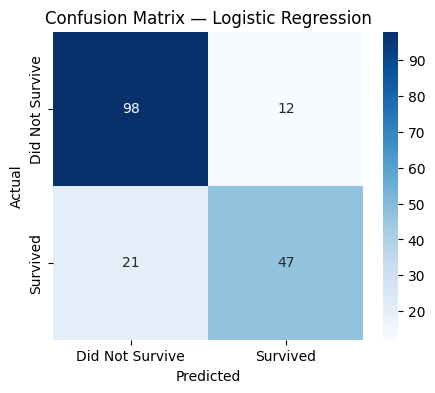

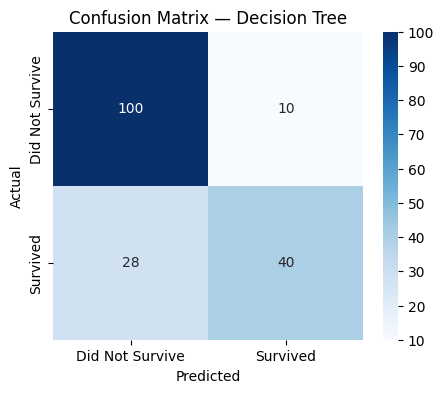

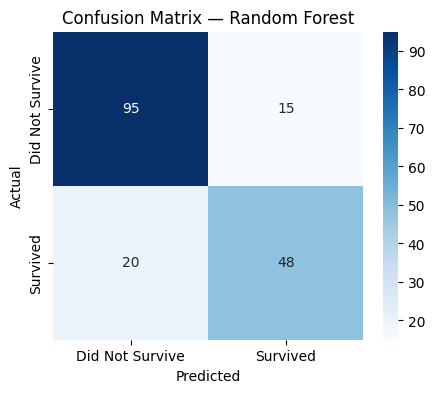

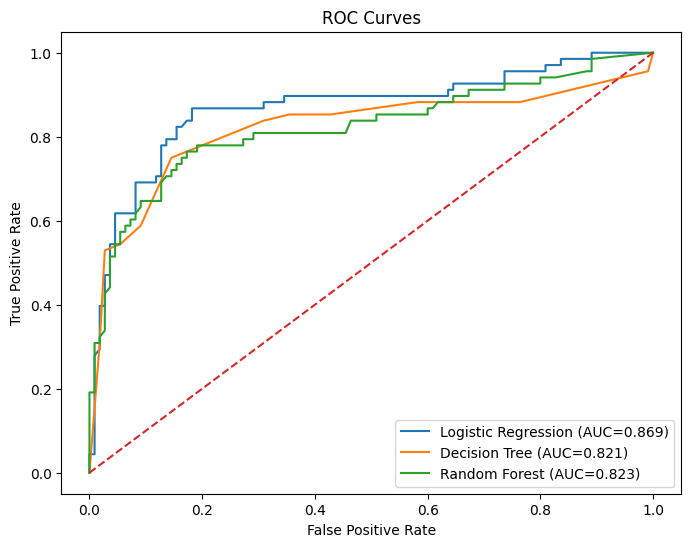

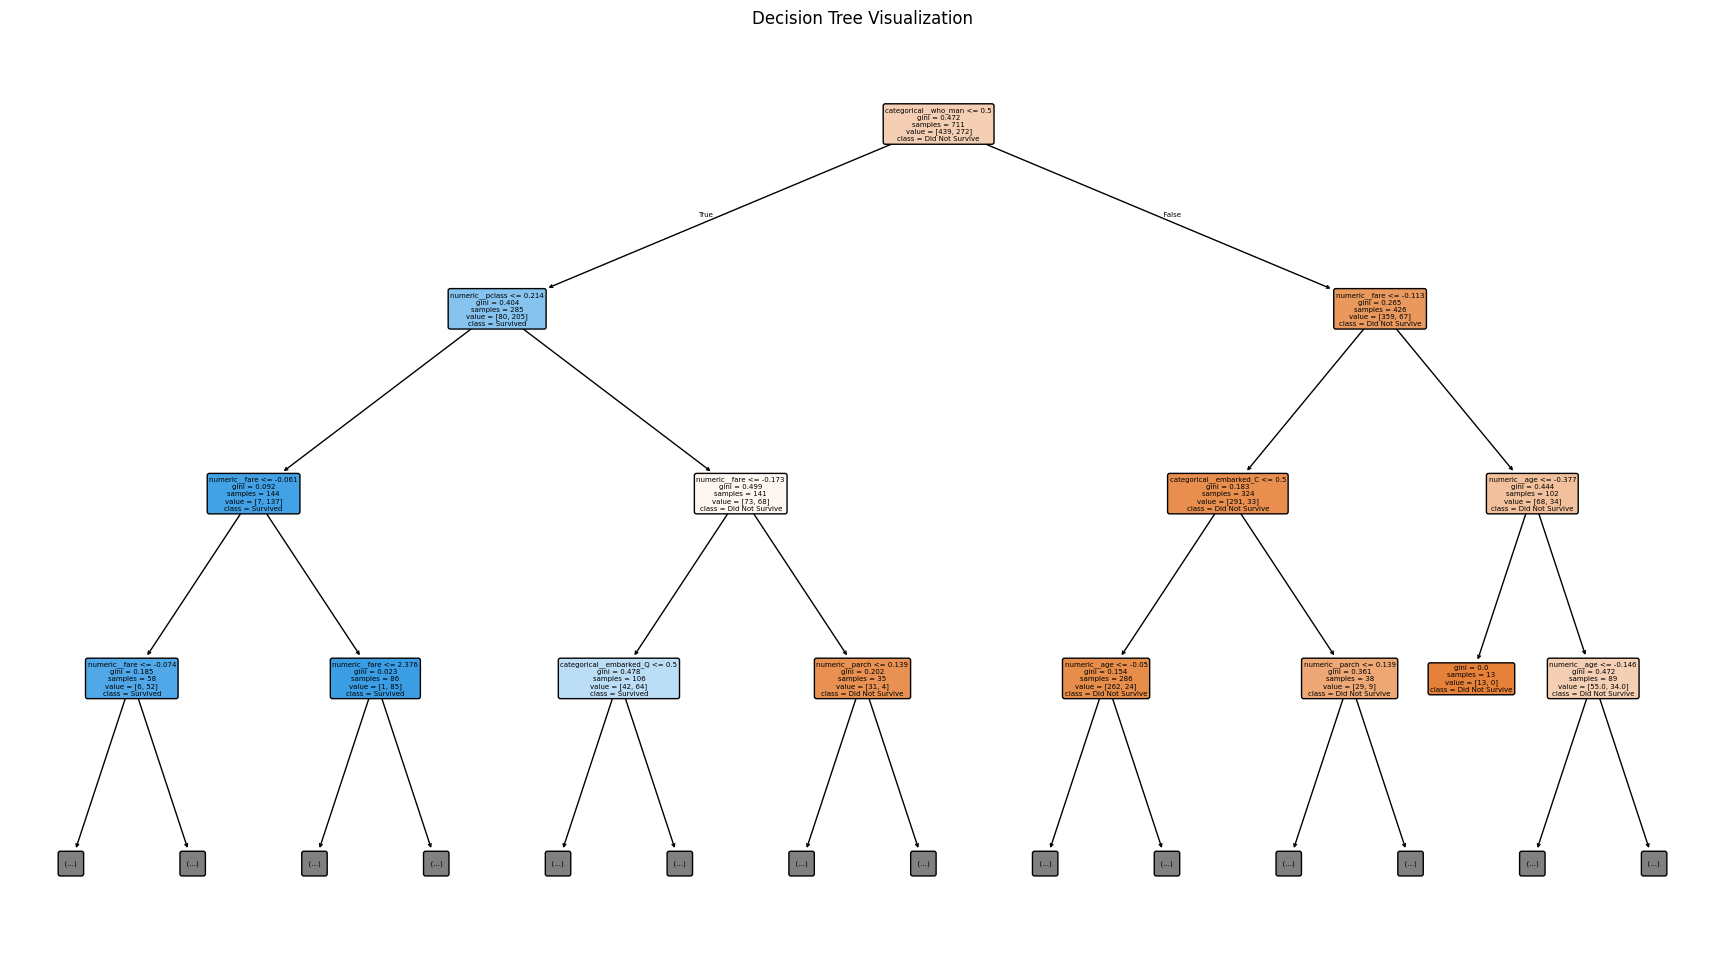

Original target distribution:


,count
survived,
0,549
1,340



Original target percentages:


,proportion
survived,
0,61.754781
1,38.245219



Baseline Logistic Regression

Confusion Matrix:
[[98 12]
 [21 47]]

Accuracy: 0.8146
Precision: 0.7966
Recall: 0.6912
F1: 0.7402
ROC-AUC: 0.8689

Balanced Logistic Regression

Confusion Matrix:
[[95 15]
 [15 53]]

Accuracy: 0.8315
Precision: 0.7794
Recall: 0.7794
F1: 0.7794
ROC-AUC: 0.8676

SMOTE Logistic Regression

Confusion Matrix:
[[96 14]
 [18 50]]

Accuracy: 0.8202
Precision: 0.7812
Recall: 0.7353
F1: 0.7576
ROC-AUC: 0.8693

Imbalance Strategy Comparison:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline Logistic Regression,0.814607,0.796610,0.691176,0.740157,0.868850
1,Balanced Logistic Regression,0.831461,0.779412,0.779412,0.779412,0.867647
2,SMOTE Logistic Regression,0.820225,0.781250,0.735294,0.757576,0.869251


Best Parameters:
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}

Best Cross-Validation F1:
0.7476219739895862

Random Forest OOB Score:
0.829817158931083

Tuned Random Forest

Confusion Matrix:
[[100  10]
 [ 22  46]]

Accuracy: 0.8202
Precision: 0.8214
Recall: 0.6765
F1: 0.7419
ROC-AUC: 0.839
Final Classification Comparison:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.814607,0.796610,0.691176,0.740157,0.868850
1,Decision Tree,0.786517,0.800000,0.588235,0.677966,0.821056
2,Random Forest,0.803371,0.761905,0.705882,0.732824,0.822527
3,Tuned Random Forest,0.820225,0.821429,0.676471,0.741935,0.839037


Regression Results:


,Metric,Value
0,MAE,21.253449
1,RMSE,42.494523
2,R²,0.323155
3,Adjusted R²,0.273930


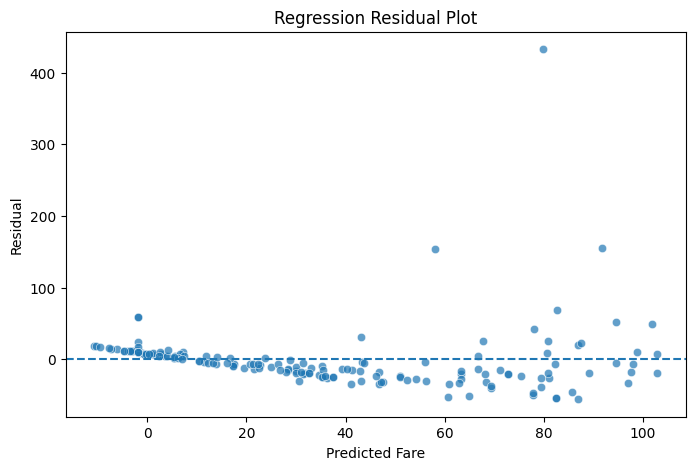

Residual variance for lower predicted fares: 184.12876085340886
Residual variance for higher predicted fares: 3937.449074751012

Heteroscedasticity conclusion:

Inspect the residual plot for whether the spread of residuals
changes as predicted fare increases. A funnel-shaped pattern
would indicate possible heteroscedasticity. A relatively
constant spread would provide less evidence of heteroscedasticity.

CLASSIFICATION MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.814607,0.796610,0.691176,0.740157,0.868850
1,Decision Tree,0.786517,0.800000,0.588235,0.677966,0.821056
2,Random Forest,0.803371,0.761905,0.705882,0.732824,0.822527
3,Tuned Random Forest,0.820225,0.821429,0.676471,0.741935,0.839037



REGRESSION MODEL COMPARISON


,Model,MAE,RMSE,R2,Adjusted_R2
0,Linear Regression,21.253449,42.494523,0.323155,0.27393



Classifier recommendation:

The classification models should be compared using multiple
metrics rather than accuracy alone. Accuracy measures overall
correct predictions, while precision, recall and F1 provide
additional information about positive-class predictions.
ROC-AUC evaluates how well the model separates the two classes.

The final model selection should therefore consider the balance
between recall, precision, F1 and ROC-AUC, together with the
model's complexity and interpretability.

The tuned Random Forest can also be compared with Logistic
Regression and Decision Tree to determine whether the additional
ensemble complexity provides useful predictive improvement.

Pipeline saved successfully:
analytics/titanic_final_pipeline.joblib
Pipeline loaded successfully.
Predicted survival: 0
Probability of survival: 0.1096
Result files saved successfully.


In [26]:
# ============================================================

# MODULE 2 — TITANIC ANALYTICS & MACHINE LEARNING

# CONTINUATION FROM BIVARIATE SURVIVAL ANALYSIS

# ============================================================

# ============================================================

# SECTION 1 — BIVARIATE VISUALIZATIONS

# ============================================================

# Survival rate by sex

plt.figure(figsize=(7, 5))
sns.barplot(
    data=df,
    x="sex",
    y="survived",
    estimator="mean"
)
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.xlabel("Sex")
plt.ylim(0, 1)
plt.show()

# Survival rate by passenger class

plt.figure(figsize=(7, 5))
sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    estimator="mean"
)
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.ylim(0, 1)
plt.show()

# Survival rate by sex and passenger class

plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex",
    estimator="mean"
)
plt.title("Survival Rate by Sex and Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.ylim(0, 1)
plt.show()

# ============================================================

# SECTION 2 — CORRELATION ANALYSIS

# ============================================================

# Requirement:

# Correlation must contain EXACTLY these six columns.

correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df[correlation_columns].corr()

print("Correlation Matrix:")
display(corr_matrix)

# Heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

# Find strongest absolute off-diagonal correlations

corr_abs = corr_matrix.abs()

# Remove diagonal

for col in corr_abs.columns:
    corr_abs.loc[col, col] = 0

# Convert matrix into pairs

corr_pairs = corr_abs.unstack().sort_values(ascending=False)

# Remove duplicate pairs

seen = set()
unique_pairs = []

for (col1, col2), value in corr_pairs.items():
    pair = tuple(sorted([col1, col2]))

    if pair not in seen:
        seen.add(pair)
        unique_pairs.append((col1, col2, value))

print("Strongest correlation pairs:")

for pair in unique_pairs[:5]:
    print(
        f"{pair[0]} vs {pair[1]}: "
        f"{corr_matrix.loc[pair[0], pair[1]]:.3f}"
    )

# ============================================================

# SECTION 3 — MULTIVARIATE VISUALIZATIONS

# ============================================================

# Chart 1: Survival by sex and class

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex",
    estimator="mean"
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

# Chart 2: Age distribution by survival

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    hue="survived",
    kde=True,
    bins=30
)

plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Passenger Count")
plt.show()

# Chart 3: Fare distribution by passenger class

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="pclass",
    y="fare"
)

plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()

# Chart 4: Age vs Fare with survival

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived",
    style="sex",
    alpha=0.7
)

plt.title("Age vs Fare by Survival and Sex")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

# ============================================================

# MULTIVARIATE INTERPRETATIONS

# ============================================================

print("""
Multivariate interpretation:

1. Survival varied substantially across passenger class and sex,
   with females and higher-class passengers generally showing
   higher survival rates.

2. The age distribution shows that survivors and non-survivors
   were distributed across several age groups, although the
   distributions are not identical.

3. Fare values differ considerably between passenger classes.
   Higher passenger classes generally contain passengers with
   higher fares, while the lower class contains many lower fares
   and several high-fare outliers.

4. The age-versus-fare plot shows that fare has a wide spread
   across ages. Survival is not explained by age or fare alone,
   suggesting that multiple passenger characteristics should
   be considered together.
   """)

# ============================================================

# SECTION 4 — STANDARDIZATION OF AGE AND FARE

# ============================================================

from sklearn.preprocessing import StandardScaler

# Requirement:

# Standardize age and fare using z-score.

# This standardized dataset is for EDA and is NOT used directly

# as the modeling preprocessing.

scaler_eda = StandardScaler()

df_eda_scaled = df.copy()

df_eda_scaled[["age", "fare"]] = scaler_eda.fit_transform(
    df_eda_scaled[["age", "fare"]]
)

print("Before standardization:")
display(df[["age", "fare"]].describe())

print("\nAfter standardization:")
display(df_eda_scaled[["age", "fare"]].describe())

print("\nMeans after standardization:")
print(df_eda_scaled[["age", "fare"]].mean())

print("\nStandard deviations after standardization:")
print(df_eda_scaled[["age", "fare"]].std())

# ============================================================

# SECTION 5 — MACHINE LEARNING DATA PREPARATION

# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# We will predict:

# survived = target

X = df.drop(columns=["survived"])

y = df["survived"]

# We do NOT use "alive" because it directly represents survival.

# We also remove "class" because it duplicates pclass.

# "adult_male" and "alone" are derived variables and are excluded

# from the six-column correlation analysis, but they can still be

# considered for modeling. To keep the model straightforward,

# we remove several redundant/target-derived columns.

columns_to_drop = [
    "alive",
    "class"
]

X = X.drop(columns=columns_to_drop)

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

# Stratified train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

# ============================================================

# SECTION 6 — PREPROCESSING PIPELINE

# ============================================================

# Numeric features

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

# Categorical features

categorical_features = [
    "sex",
    "embarked",
    "who"
]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created successfully.")

# ============================================================

# SECTION 7 — THREE CLASSIFICATION MODELS

# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42,
            max_depth=5
        ))
    ]
)

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

# Train models

logistic_model.fit(X_train, y_train)
decision_tree_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

print("All three classification models trained successfully.")

# ============================================================

# SECTION 8 — MODEL EVALUATION FUNCTION

# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import numpy as np

def evaluate_classifier(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)

    # Probability for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    cm = confusion_matrix(y_test, y_pred)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    print("\nConfusion Matrix:")
    print(cm)

    print("\nAccuracy:", round(metrics["Accuracy"], 4))
    print("Precision:", round(metrics["Precision"], 4))
    print("Recall:", round(metrics["Recall"], 4))
    print("F1:", round(metrics["F1"], 4))
    print("ROC-AUC:", round(metrics["ROC_AUC"], 4))

    return metrics

# Evaluate all three

logistic_results = evaluate_classifier(
    logistic_model,
    X_test,
    y_test,
    "Logistic Regression"
)

decision_tree_results = evaluate_classifier(
    decision_tree_model,
    X_test,
    y_test,
    "Decision Tree"
)

random_forest_results = evaluate_classifier(
    random_forest_model,
    X_test,
    y_test,
    "Random Forest"
)

# Comparison table

classification_results = pd.DataFrame([
    logistic_results,
    decision_tree_results,
    random_forest_results
])

print("\nClassification Model Comparison:")
display(classification_results)

# ============================================================

# SECTION 9 — CONFUSION MATRICES

# ============================================================

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Did Not Survive", "Survived"],
        yticklabels=["Did Not Survive", "Survived"]
    )

    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ============================================================

# SECTION 10 — ROC CURVES

# ============================================================

plt.figure(figsize=(8, 6))

for name, model in models.items():

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_test)[:, 1]
    else:
        probabilities = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc_score = roc_auc_score(y_test, probabilities)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# ============================================================

# SECTION 11 — DECISION TREE VISUALIZATION

# ============================================================

from sklearn.tree import plot_tree

# Get trained preprocessing component

tree_preprocessor = decision_tree_model.named_steps["preprocessor"]

# Get trained decision tree

tree_classifier = decision_tree_model.named_steps["classifier"]

# Get generated feature names

feature_names = tree_preprocessor.get_feature_names_out()

plt.figure(figsize=(22, 12))

plot_tree(
    tree_classifier,
    feature_names=feature_names,
    class_names=["Did Not Survive", "Survived"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree Visualization")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

# ============================================================

# SECTION 12 — CLASS IMBALANCE

# ============================================================

print("Original target distribution:")
display(y.value_counts())

print("\nOriginal target percentages:")
display(y.value_counts(normalize=True) * 100)

# ------------------------------------------------------------

# Baseline Logistic Regression

# ------------------------------------------------------------

baseline_lr = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

baseline_lr.fit(X_train, y_train)

baseline_results = evaluate_classifier(
    baseline_lr,
    X_test,
    y_test,
    "Baseline Logistic Regression"
)

# ------------------------------------------------------------

# Balanced Logistic Regression

# ------------------------------------------------------------

balanced_lr = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

balanced_lr.fit(X_train, y_train)

balanced_results = evaluate_classifier(
    balanced_lr,
    X_test,
    y_test,
    "Balanced Logistic Regression"
)

# ============================================================

# SECTION 13 — SMOTE

# ============================================================

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# IMPORTANT:

# SMOTE is applied only after the train/test split.

# Therefore, synthetic observations are generated only from

# the training data and cannot leak information from the test set.

smote_lr = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

smote_lr.fit(X_train, y_train)

smote_results = evaluate_classifier(
    smote_lr,
    X_test,
    y_test,
    "SMOTE Logistic Regression"
)

# Compare imbalance strategies

imbalance_results = pd.DataFrame([
    baseline_results,
    balanced_results,
    smote_results
])

print("\nImbalance Strategy Comparison:")
display(imbalance_results)

# ============================================================

# SECTION 14 — RANDOM FOREST GRIDSEARCHCV

# ============================================================

from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            random_state=42,
            oob_score=True
        ))
    ]
)

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1:")
print(grid_search.best_score_)

best_rf = grid_search.best_estimator_

# OOB score

best_rf_classifier = best_rf.named_steps["classifier"]

print("\nRandom Forest OOB Score:")
print(best_rf_classifier.oob_score_)

# Evaluate best RF on test set

best_rf_results = evaluate_classifier(
    best_rf,
    X_test,
    y_test,
    "Tuned Random Forest"
)

# ============================================================

# SECTION 15 — FINAL DECISION TREE / RF MODEL COMPARISON

# ============================================================

final_classification_results = pd.DataFrame([
    logistic_results,
    decision_tree_results,
    random_forest_results,
    best_rf_results
])

print("Final Classification Comparison:")
display(final_classification_results)

# ============================================================

# SECTION 16 — REGRESSION: PREDICT FARE

# ============================================================

# Regression target

# We predict fare from other passenger features.

regression_df = df.copy()

# Fare is the target, so remove it from features.

X_reg = regression_df.drop(columns=["fare"])

y_reg = regression_df["fare"]

# Remove variables that directly represent survival.

# This side task is focused on predicting fare from passenger

# characteristics.

regression_drop = [
    "alive",
    "survived",
    "class"
]

X_reg = X_reg.drop(columns=regression_drop)

# Identify columns

reg_numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical_features = [
    "sex",
    "embarked",
    "who"
]

reg_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

reg_categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            reg_numeric_pipeline,
            reg_numeric_features
        ),
        (
            "categorical",
            reg_categorical_pipeline,
            reg_categorical_features
        )
    ],
    remainder="drop"
)

# Train/test split

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Regression model

from sklearn.linear_model import LinearRegression

regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("regressor", LinearRegression())
    ]
)

regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

# Predictions

y_reg_pred = regression_pipeline.predict(X_reg_test)

# ============================================================

# SECTION 17 — REGRESSION METRICS

# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_reg_test,
    y_reg_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_reg_pred
    )
)

r2 = r2_score(
    y_reg_test,
    y_reg_pred
)

# Adjusted R-squared

n = len(y_reg_test)

# Number of predictor columns after preprocessing

p = regression_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out().shape[0]

adjusted_r2 = (
    1 -
    ((1 - r2) * (n - 1) / (n - p - 1))
)

regression_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²",
        "Adjusted R²"
    ],
    "Value": [
        mae,
        rmse,
        r2,
        adjusted_r2
    ]
})

print("Regression Results:")
display(regression_results)

# ============================================================

# SECTION 18 — RESIDUAL PLOT

# ============================================================

residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_reg_pred,
    y=residuals,
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Regression Residual Plot")
plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.show()

# Basic heteroscedasticity interpretation

residual_variance_low = residuals[
    y_reg_pred <= y_reg_pred.mean()
].var()

residual_variance_high = residuals[
    y_reg_pred > y_reg_pred.mean()
].var()

print("Residual variance for lower predicted fares:",
      residual_variance_low)

print("Residual variance for higher predicted fares:",
      residual_variance_high)

print("""
Heteroscedasticity conclusion:

Inspect the residual plot for whether the spread of residuals
changes as predicted fare increases. A funnel-shaped pattern
would indicate possible heteroscedasticity. A relatively
constant spread would provide less evidence of heteroscedasticity.
""")

# ============================================================

# SECTION 19 — FINAL MODEL COMPARISON TABLE

# ============================================================

# Classification metrics

classification_summary = final_classification_results[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
].copy()

print("CLASSIFICATION MODEL COMPARISON")
display(classification_summary)

# Regression metrics separately

regression_summary = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2],
    "Adjusted_R2": [adjusted_r2]
})

print("\nREGRESSION MODEL COMPARISON")
display(regression_summary)

# ============================================================

# SECTION 20 — CLASSIFIER RECOMMENDATION

# ============================================================

print("""
Classifier recommendation:

The classification models should be compared using multiple
metrics rather than accuracy alone. Accuracy measures overall
correct predictions, while precision, recall and F1 provide
additional information about positive-class predictions.
ROC-AUC evaluates how well the model separates the two classes.

The final model selection should therefore consider the balance
between recall, precision, F1 and ROC-AUC, together with the
model's complexity and interpretability.

The tuned Random Forest can also be compared with Logistic
Regression and Decision Tree to determine whether the additional
ensemble complexity provides useful predictive improvement.
""")

# ============================================================

# SECTION 21 — SAVE COMPLETE FITTED CLASSIFICATION PIPELINE

# ============================================================

import joblib

# Save the tuned Random Forest pipeline.

# This contains:

# 1. preprocessing

# 2. encoding

# 3. scaling

# 4. trained Random Forest

model_path = "analytics/titanic_final_pipeline.joblib"

joblib.dump(
    best_rf,
    model_path
)

print("Pipeline saved successfully:")
print(model_path)

# ============================================================

# SECTION 22 — RELOAD SAVED PIPELINE

# ============================================================

loaded_pipeline = joblib.load(
    model_path
)

print("Pipeline loaded successfully.")

# ============================================================

# SECTION 23 — PREDICT RAW INPUT

# ============================================================

# IMPORTANT:

# These values are RAW input.

# We do not manually encode or scale them.

# The saved pipeline performs preprocessing automatically.

raw_input = pd.DataFrame({
    "pclass": [3],
    "sex": ["male"],
    "age": [25],
    "sibsp": [0],
    "parch": [0],
    "fare": [10.5],
    "embarked": ["S"],
    "who": ["man"],
    "adult_male": [True],
    "alone": [True]
})

prediction = loaded_pipeline.predict(
    raw_input
)

prediction_probability = loaded_pipeline.predict_proba(
    raw_input
)[:, 1]

print("Predicted survival:", prediction[0])
print("Probability of survival:", round(
    prediction_probability[0],
    4
))

# ============================================================

# SECTION 24 — SAVE IMPORTANT MODEL OUTPUTS

# ============================================================

classification_summary.to_csv(
    "analytics/classification_results.csv",
    index=False
)

regression_summary.to_csv(
    "analytics/regression_results.csv",
    index=False
)

imbalance_results.to_csv(
    "analytics/imbalance_results.csv",
    index=False
)

print("Result files saved successfully.")

# ============================================================

# SECTION 25 — FINAL CHECK

# ============================================================

# print("""

# MODULE 2 COMPLETION CHECK

# Titanic loaded exactly once
# Titanic fallback CSV saved
# Dataset profiling completed
# Missing-value percentages calculated
# Missing values handled
# Age histogram and boxplot
# Fare histogram and boxplot
# IQR outlier analysis
# Fare mean / median / mode / skewness
# Survival by sex
# Survival by passenger class
# Survival by sex + passenger class
# Six-column correlation matrix
# Correlation heatmap
# Four multivariate visualizations
# Age/fare standardization for EDA
# Stratified train/test split
# Train-only preprocessing pipeline
# Logistic Regression
# Decision Tree
# Random Forest
# Confusion matrices
# Accuracy / Precision / Recall / F1
# ROC / AUC
# Decision Tree visualization
# Class imbalance baseline
# class_weight='balanced'
# SMOTE on training data
# Random Forest GridSearchCV
# Random Forest OOB score
# Fare regression
# MAE / RMSE / R^2 / Adjusted R^2
# Residual plot
# Classification comparison
# Regression comparison
# Complete fitted pipeline saved
# Saved pipeline reloaded
# Raw input prediction tested

# ============================================================
# ""
# )